# Netflix Content Analysis 

-----

## 1. Business Understanding

### 1.1 Overview

Project-X plans to develop a new movie script by analyzing data from **Netflix** to uncover patterns, trends and insight that will guide creative and strategic decisions. 

The goal is to understand what kind of content performs well, what audiences are exposed to most and where opportunities lie in the entertainment landscape.

### 1.2 Problem Statement

Creating a succesful movie is not about creativity; It's about timing, audience, prefrence and market awarness.

The stakeholders currently lack data-driven insights into:

- Which genres are most popular globally
- How content production trends have evolved over time
- What ratings dominate the platform
- Which countries are leading in content creation 
- Whether movies or TV shows dominate the platform

Without this information, there is a risk of developing content that does not align with audience demand or industry trends.

### 1.3 Objective

The objective of Project-X is to extract actionable insights from the **Netflix** dataset to support the development of a successful movie script.

Specifically, the project aims to:

- Identify the **top 10 genres worldwide** to guide story direction
- Analyze **total movies and TV shows by year** to understand industry trends
- Examine **ratings distribution (e.g., TV-14, PG-13)** to determine target audience
- Evaluate **content production by country** to identify dominant markets
- Determine the **percentage distribution of movies vs TV shows**


### 1.4 Success Metrics

This project will be successful if it meets the following metrics:

- Identifies the most dominant and trending genres
- Clearly shows how content production has changed over time
- Provides insight into the most common audience ratings
- Highlights leading countries in content production
- Reveals whether movies or TV shows dominate the platform
- Generates insights that can directly influence script development decisions


### 1.5 Constraints 

Some limitations of this analysis include:

- Data Quality Issues: Missing values, inconsistent formatting and potential inaccuracies. 
- Dataset Coverage: The dataset may not represent the full Netflix catalog
- Popularity is inferred indirectly (e.g., via ratings), not actual view counts
- No real-time or recent data updates

### 1.6 Stakeholders

The key stakeholders of this project are: 

- Directors : Responsible for shaping the creative vision and ensuring the final output aligns with storytelling goals.
- Writers : Develops compelling narratives and scripts that drive audinceengagement.
- Producers : Oversee the overall execution of the project, managing resources, budgets, and timelines to ensure smooth delivery.
- Production Company: Provide the infrastructure, funding, and strategic direction needed to bring content from concept to completion.

----

## 2. Data Understanding 

### 2.1 Data Source

The dataset used for this analysis is sourced from a Netflix content dataset from Kaggle up to 2020. 

**Format:** CSV file

**Content:** Includes attributes such as title, type (Movie/TV Show), genre, country, release year, duration, and rating

**Scope:** Global Netflix content across multiple years

| Item  | Detail |
|:-----------|:------------:|
| Datset     | Netflix_Titles        |
| Coverage | 2008-2020 releases |
| Content | 
| Tools | Python . pandas .NumPy . Seaborn . Matplotlib . SciPy |
|Chart types | Line . Bar . Chorpleth / Map-based plots |


### Importing Libraries

This are libraries that will be required for this project 

In [42]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Loading the Data set

In [43]:
netflix = pd.read_csv('netflix_titles.csv')

### Data Preview

In [44]:
# Find shape of the data(rows, columns)
print(f"Netflix shape:{netflix.shape}")

Netflix shape:(6234, 12)


In [45]:
# Find column names 
print(f"Netflix columns:{netflix.columns}")

Netflix columns:Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


| Column Name   | Description |
|---------------|------------|
| show_id       | Unique identifier for each title |
| type          | Indicates whether the content is a Movie or TV Show |
| title         | Name of the movie or TV show |
| director      | Director of the content |
| cast          | Main actors featured in the content |
| country       | Country where the content was produced |
| date_added    | Date the content was added to Netflix |
| release_year  | Year the content was originally released |
| rating        | Content rating (e.g., TV-14, PG-13) |
| duration      | Length of the content (minutes or seasons) |
| listed_in     | Genre/category of the content |
| description   | Brief summary of the content |

### 2.2 Data Preparation

This is where data is cleaned to ensure data accuracy, consistency and readiness for use.

In [46]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [47]:
### Checking for missing values
netflix.isnull().sum().sort_values(ascending=False)

director        1969
cast             570
country          476
date_added        11
rating            10
show_id            0
type               0
title              0
release_year       0
duration           0
listed_in          0
description        0
dtype: int64

### Handling Missing Values

In [48]:
# Handle missing data by filling with 'Unknown'
netflix['director'].fillna('Unknown', inplace=True)
netflix['cast'].fillna('Unknown', inplace=True)
netflix['country'].fillna('Unknown', inplace=True)
netflix['date_added'].fillna('Not Available', inplace=True)
netflix['rating'].fillna('Not Rated', inplace=True)

In [49]:
# Verify that there are no more missing values
netflix.isnull().sum().sort_values(ascending=False)

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

-----
## 3. Data Analysis and Visualization

### *Question 1: What are the top 10 genres worldwide?*


In [50]:
# Check column data
netflix['listed_in'].head()

0    Children & Family Movies, Comedies
1                       Stand-Up Comedy
2                              Kids' TV
3                              Kids' TV
4                              Comedies
Name: listed_in, dtype: object

In [51]:
# Split the geres column into a list of genres
netflix['listed_in'] = netflix['listed_in'].str.split(', ')

In [52]:
# Explode the Column
netflix_exploded = netflix.explode('listed_in')

In [53]:
# Count Genre Frequency
genre_counts = netflix_exploded['listed_in'].value_counts()

In [54]:
# Get the top 10 genres
top10_genres = genre_counts.head(10)
print(top_genres)

Series([], Name: count, dtype: int64)


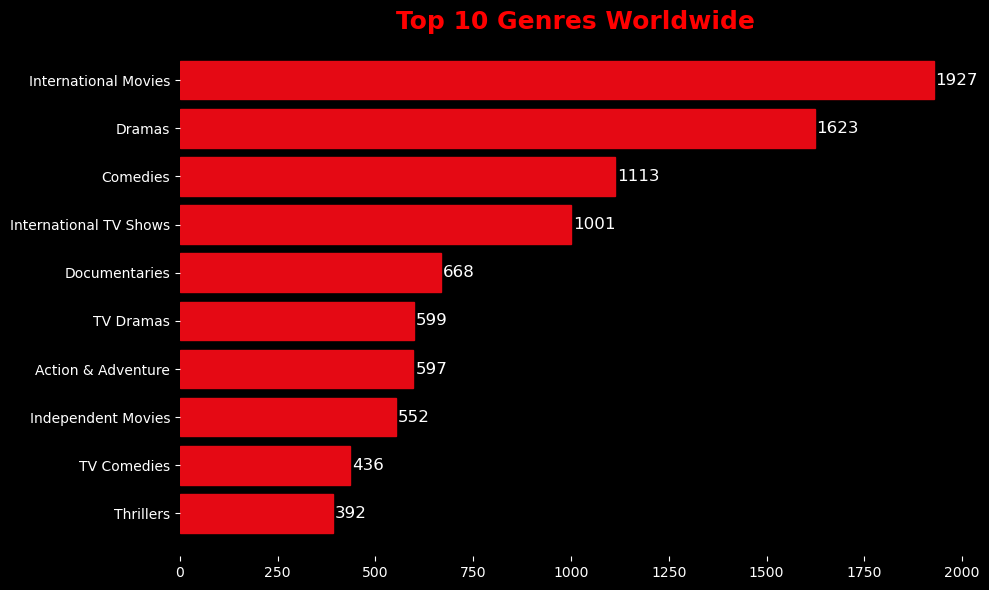

In [55]:
# Ensure top10_genres is sorted (ascending for horizontal bar)
top10_genres = top10_genres.sort_values()

# Create figure
plt.figure(figsize=(10,6))

# Dark background
plt.style.use('dark_background')

# Plot horizontal bars
bars = plt.barh(top10_genres.index, top10_genres.values)

# Color (Netflix red vibe)
for bar in bars:
    bar.set_color('#E50914')  # Netflix red

# Title
plt.title('Top 10 Genres Worldwide', fontsize=18, color='red', weight='bold')

# Remove spines (clean look)
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Remove grid
plt.grid(False)

# Axis labels (optional minimal look)
plt.xlabel('')
plt.ylabel('')

# Add value labels at end of bars
for index, value in enumerate(top10_genres.values):
    plt.text(value + 5, index, str(value), va='center', color='white', fontsize=12)

# Tight layout for clean spacing
plt.tight_layout()

plt.show()

### *Findings*

The `listed_in` column contained multiple genres per entry, separated by commas. To properly analyze it, I cleaned the data by splitting the values at each comma and restructuring them so that each genre could be treated individually. This allowed for a more accurate aggregation and ensured that all genres were counted consistently in the analysis.


The analysis reveals that genres such as International Movies and Dramas dominate the Netflix Catalog, appearing significantly more frequently than other categories. This suggest a strong global prefrence for emotionally driven narratives and culturally diverse storytelling. 

Additionally, the presence of genre combinations indicates that Netflix frequently blends genres to appeal to a wider audience. The hybrid categorization reflects a strategy aimed to maximizing viewer engagement across different tastes. 

Less dominant genre appear with lower frequency, suggesting either niche audience appeal or underrepresentation in the platform's content strategy. 

### *Recommendation*
- **International Movies and Dramas clearly dominate user exposure**, reflecting strong global demand for emotionally rich and culturally diverse storytelling. From a business standpoint, stakeholders aiming for **quick and reliable** returns should continue prioritizing investment in these genres, as they already show proven audience traction and high visibility on the platform.
- At the same time, there is a clear opportunity to **expand into underrepresented genres** to diversify the catalog and attract niche audiences who may currently feel underserved. This path is more of a **long-term growth strategy**, suited for stakeholders willing to take calculated risks and explore new markets beyond the platform’s dominant content trends. 

-----

### *Question 2: What is the distribution of Movies VS TV Shows?*


In [65]:
type_counts = netflix['type'].value_counts()
print(type_counts)

type
Movie      4265
TV Show    1969
Name: count, dtype: int64


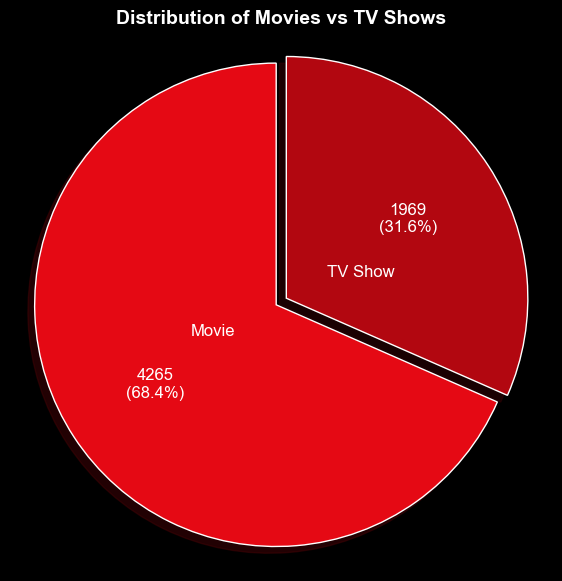

In [ ]:
# Red shades
colors = ['#E50914', '#B20710']

plt.figure(figsize=(7,7), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Custom function to show label + count + %
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{val}\n({pct:.1f}%)'
    return my_format

plt.pie(
    type_counts,
    labels=type_counts.index,
    colors=colors,
    startangle=90,
    explode=(0.05, 0),
    shadow=True,
    autopct=autopct_format(type_counts),
    textprops={'color': 'white', 'fontsize': 12},
    labeldistance=0.2  # pushes labels inside
)

plt.title(
    'Distribution of Movies vs TV Shows',
    fontsize=14,
    fontweight='bold',
    color='white'
)

plt.axis('equal')  # perfect circle

plt.show()

### *Findings*

- The dataset shows a **clear dominance of Movies over TV Shows**, indicating that Netflix’s catalog is still largely movie-driven in terms of volume.
- TV Shows make up a **smaller but still significant portion**, showing that serialized content is present but not the primary focus in terms of count.
- The difference in counts suggests a **content strategy that historically prioritized movies**, likely due to faster production cycles and broader global licensing availability.
- Despite being fewer in number, TV Shows remain strategically important because they typically drive **longer viewer engagement and repeat watch sessions** compared to movies.



### *Recommendation*

- Given that **Movies dominate the catalog by volume**, stakeholders should maintain this strength but avoid over-reliance on it. A high movie count supports variety, but it does not automatically guarantee long-term user retention.
- Since **TV Shows are fewer but typically drive higher engagement and repeat viewing**, stakeholders should consider **strategically increasing investment in TV Show production and acquisition**. This would help balance the catalog between volume (Movies) and retention-driven content (TV Shows).
 --------


### *Question 3: What are the total numbers of Movies & TV Shows by year?*


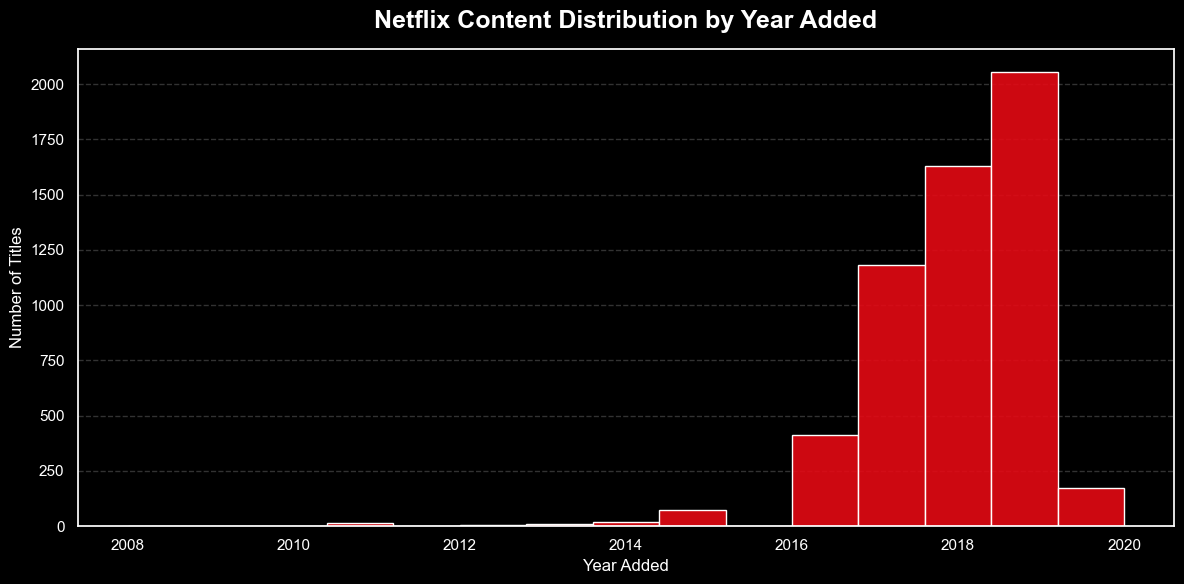

In [ ]:
# Set dark theme
sns.set_theme(style="dark")

plt.figure(figsize=(12,6), facecolor='black')

ax = sns.histplot(
    data=netflix,
    x='year_added',
    bins=15,
    color='#E50914',
    edgecolor='white',
    alpha=0.9
)

# Set axis background to black
ax.set_facecolor('black')

# Title + labels in white for contrast
plt.title(
    'Netflix Content Distribution by Year Added',
    fontsize=18,
    fontweight='bold',
    color='white',
    pad=15
)

plt.xlabel('Year Added', color='white')
plt.ylabel('Number of Titles', color='white')

# Make ticks white too
plt.xticks(color='white')
plt.yticks(color='white')

# Grid styling (subtle like dashboards)
plt.grid(axis='y', linestyle='--', alpha=0.2, color='white')
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

### *Findings*

- Netflix shows a **strong concentration of content added in recent years**, especially from **2017 onward**, confirming rapid platform expansion during its global growth phase.
- The **peak period appears around 2018–2020**, where the number of titles added is significantly higher than earlier years. This reflects Netflix’s aggressive push into **original productions and international licensing**.
- The overall distribution is **heavily right-skewed**, meaning Netflix continuously prioritizes newer additions to keep the platform fresh and competitive.
- Any slight decline in the most recent year likely reflects **incomplete yearly data or shifting content acquisition cycles**, rather than an actual drop in strategy.

### *Recommendation*
- Stakeholders should recognize that the strong concentration of content additions in recent years (especially post-2017) reflects a successful scaling strategy. To sustain this momentum, continued investment in rapid content acquisition and production pipelines is recommended, particularly in markets where growth is still emerging.
- The spike in additions during peak years suggests that aggressive expansion works, but it also raises a strategic question: growth alone is not enough. Stakeholders should now shift focus toward balancing volume with content quality and long-term retention impact, ensuring that high addition rates translate into sustained viewer engagement.

--------

### *Question 4: What are the hightest ranking ratings?*


In [74]:
# Count ratings
rating_counts = netflix['rating'].value_counts().sort_values(ascending=False)
print(rating_counts)

rating
TV-MA        2027
TV-14        1698
TV-PG         701
R             508
PG-13         286
NR            218
PG            184
TV-Y7         169
TV-G          149
TV-Y          143
TV-Y7-FV       95
G              37
Not Rated      10
UR              7
NC-17           2
Name: count, dtype: int64


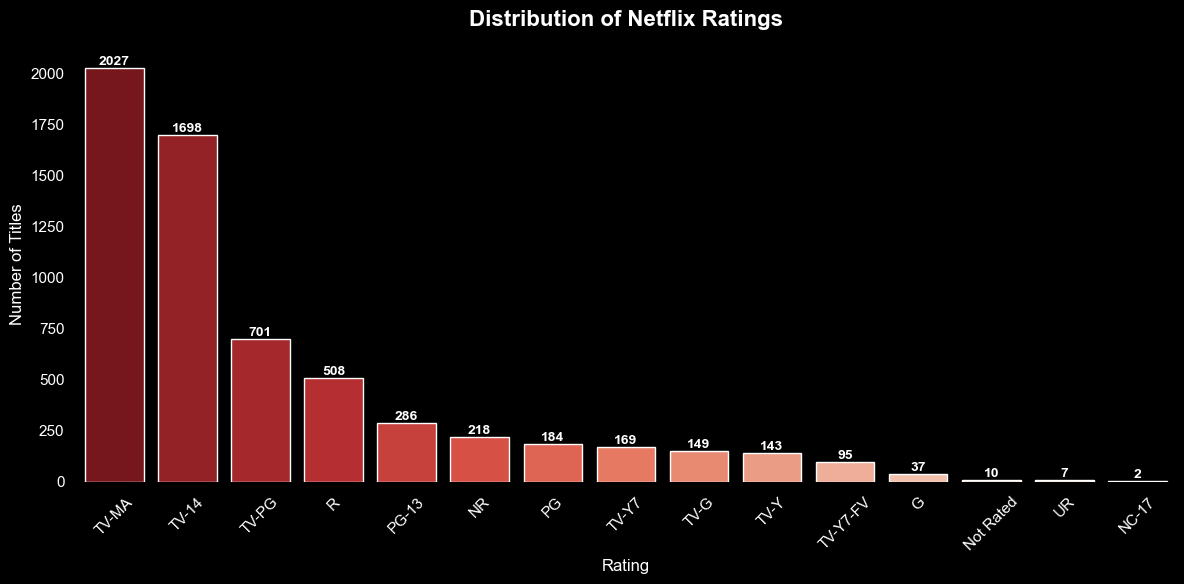

In [ ]:
# Dark theme setup
plt.figure(figsize=(12,6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Bar chart
bars = sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values,
    palette='Reds_r'
)

# Add value labels on top of bars
for bar in bars.patches:
    bars.annotate(
        format(bar.get_height(), '.0f'),
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

# Titles and labels
plt.title(
    'Distribution of Netflix Ratings',
    fontsize=16,
    fontweight='bold',
    color='white',
    pad=15
)

plt.xlabel('Rating', color='white')
plt.ylabel('Number of Titles', color='white')

# Tick styling
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')

# No grid
ax.grid(False)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### *Findings*
- The ratings are **heavily concentrated in a few categories**, typically led by **TV-MA and TV-14**, indicating that most content is targeted toward **mature and young adult audiences** rather than children.
- There is a **clear skew toward mature content** indicating higher engagement and longer watch times.


### *Recommendation*

- There is a clear opportunity to **expand family-friendly and children’s content**, which is currently underrepresented. This segment can drive **household subscriptions and long-term viewer loyalty**, especially in global markets with younger populations.


-----

### *Question 5: What are the total numbers of Movies & TV Shows by Country?*


In [81]:
# Drop missing values
country_data = netflix.dropna(subset=['country']).copy()

# Split multiple countries into rows
country_data['country'] = country_data['country'].str.split(', ')

# Explode into separate rows
country_data = country_data.explode('country')

# Count Movies vs TV Shows by country
country_type_counts = country_data.groupby(['country', 'type']).size().reset_index(name='count')

# Get top 10 countries by total content
top_countries = (
    country_data['country']
    .value_counts()
    .head(10)
    .index
)

# Filter for top countries only
country_type_counts = country_type_counts[country_type_counts['country'].isin(top_countries)]

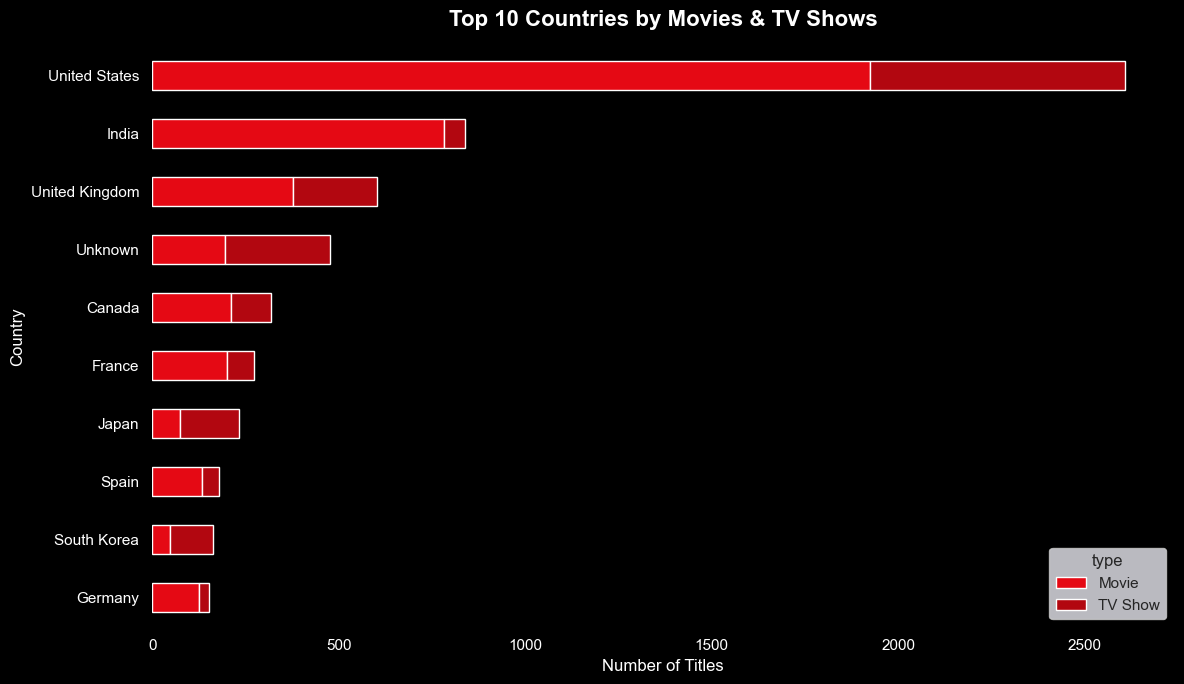

In [86]:
# Pivot for stacked bar
pivot_df = country_type_counts.pivot(index='country', columns='type', values='count').fillna(0)

# Sort by total
pivot_df['Total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values('Total', ascending=True)

# Dark theme
plt.figure(figsize=(12,7), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Plot stacked bars
pivot_df[['Movie', 'TV Show']].plot(
    kind='barh',
    stacked=True,
    color=['#E50914', '#B20710'],
    ax=ax
)

# Labels & title
plt.title(
    'Top 10 Countries by Movies & TV Shows',
    fontsize=16,
    fontweight='bold',
    color='white',
    pad=15
)

plt.xlabel('Number of Titles', color='white')
plt.ylabel('Country', color='white')

# Styling
plt.xticks(color='white')
plt.yticks(color='white')

ax.grid(False)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


### *Findings*

- The map reveals a **strong concentration of content in a few key countries**, with the **United States leading by a significant margin**, followed by countries like **India and the United Kingdom**. This shows that content production is heavily centralized rather than globally balanced.
- The distribution highlights a **global imbalance**, where a small number of countries dominate the majority of Netflix’s catalog, while many others contribute very little.
- Countries with strong film industries and infrastructure tend to have **higher content counts**, suggesting that production capacity and industry maturity play a major role in content availability on the platform.

### *Recommendation*
Right now, the map shows concentration. The opportunity lies in distribution of investment, those who move early into underrepresented regions won’t just follow the market, they’ll shape it.

------

## 4. Conclusion

### 4.1 Key Findings

- Audience Preference
Content trends show strong demand for Dramas and International storytelling, especially those with emotional depth and cultural relevance.
- Content Format
While Movies dominate in number, TV Shows drive stronger engagement over time, making them ideal for building loyal audiences.
- Genre Strategy
The frequent use of hybrid genres (e.g., Drama + Romance, Thriller + Crime) shows that audiences respond well to blended storytelling, not one-dimensional categories.
- Target Audience (Ratings)
Most content is targeted toward mature and young adult audiences (TV-MA, TV-14), indicating that this demographic is the most active and engaged.
- Global Appeal
Content from a few countries dominates, but there is growing demand for diverse, culturally unique stories, especially those that can cross borders.

### 4.2 Strategic Recommendations

- **Leverage dominant genres**

    Focus on Drama-based storytelling, but ensure originality to stand out

- **Adopt hybrid storytelling**

    Combine a strong genre with a niche twist to increase audience reach

- **Target the right rating**

    Prioritize TV-MA / TV-14 content, where engagement is highest

- **Choose format intentionally**

    Align format (Movie vs TV Show) with your goal:
        - Quick visibility vs long-term audience retention

- **Design for global appeal**

    Create stories rooted in local culture but driven by universal themes

### 4.3 Final Insight

**Blend what works with what's missing**

